# Processing Sequences Using RNNs and CNNs

In [ ]:
from pathlib import Path
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

## Forecasting Time Series

In [3]:
ds_path = Path('/kaggle/input/datasets/harshit1234g/cta-ridership/CTA_Ridership.csv')

In [4]:
# loading dataset
df = pd.read_csv(ds_path, parse_dates= ['service_date'])

# column preprocessing
df = df.drop('total_rides', axis= 1)    # because it is only bus + rail
df.columns = ['date', 'day_type', 'bus', 'rail']

# converting bus and rail to int
df['bus'] = df['bus'].str.replace(',', '').astype('int64')
df['rail'] = df['rail'].str.replace(',', '').astype('int64')

# sorting using dates
df = df.sort_values('date').set_index('date')
df = df.drop_duplicates()

In [5]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9190 entries, 2001-01-01 to 2026-02-28
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   day_type  9190 non-null   object
 1   bus       9190 non-null   int64 
 2   rail      9190 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 287.2+ KB


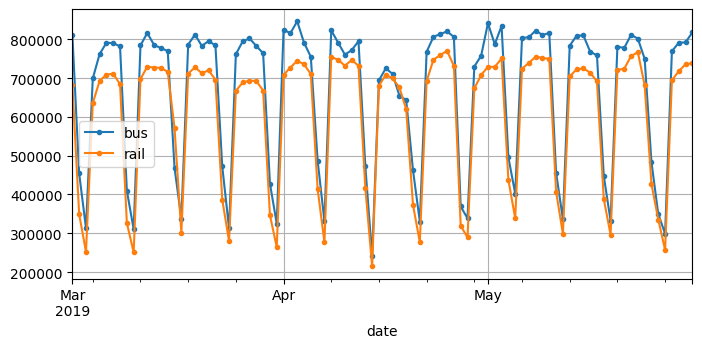

In [7]:
df['2019-03':'2019-05'].plot(grid= True, marker= '.', figsize= (8, 3.5))
plt.show()

### Naive Forecasting

In [8]:
diff_week = df[['bus', 'rail']].diff(7)['2019-03':'2019-05']

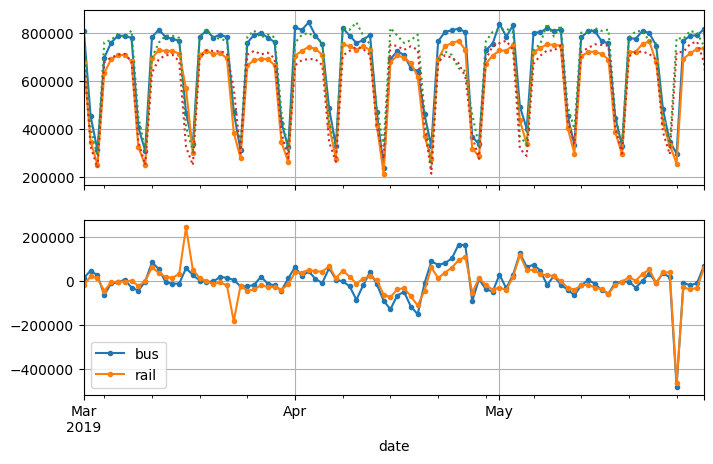

In [9]:
fig, axes = plt.subplots(2, 1, sharex= True, figsize= (8, 5))
df.plot(ax= axes[0], legend= False, marker= '.')                            # original time series
df.shift(7).plot(ax= axes[0], grid= True, legend= False, linestyle= ':')    # lagged series
diff_week.plot(ax= axes[1], grid= True, marker= '.')                        # 7-day difference series
axes[0].set_ylim([170_000, 900_000])
plt.show()

In [10]:
diff_week.abs().mean()    # MAE

bus     43915.608696
rail    42143.271739
dtype: float64

In [11]:
targets = df[['bus', 'rail']]['2019-03':'2019-05']
(diff_week / targets).abs().mean()   # MAPE

bus     0.082938
rail    0.089948
dtype: float64

### Yearly seasonality

In [12]:
period = slice('2001', '2019')
df_monthly = df.select_dtypes(include= 'number').resample('ME').mean()     # compute mean for each month
rolling_avg_12_months = df_monthly[period].rolling(window= 12).mean()

In [13]:
df_monthly.head()

,bus,rail
date,,
2001-01-31,807190.580645,474591.419355
2001-02-28,848889.000000,488188.178571
2001-03-31,865392.419355,498825.096774
2001-04-30,835126.366667,490444.533333
2001-05-31,862701.419355,507862.258065


In [14]:
rolling_avg_12_months

,bus,rail
date,,
2001-01-31,NaN,NaN
2001-02-28,NaN,NaN
2001-03-31,NaN,NaN
2001-04-30,NaN,NaN
2001-05-31,NaN,NaN
...,...,...
2019-08-31,653301.645533,605589.250966
2019-09-30,653812.309421,603990.406522
2019-10-31,651295.035228,601386.350070


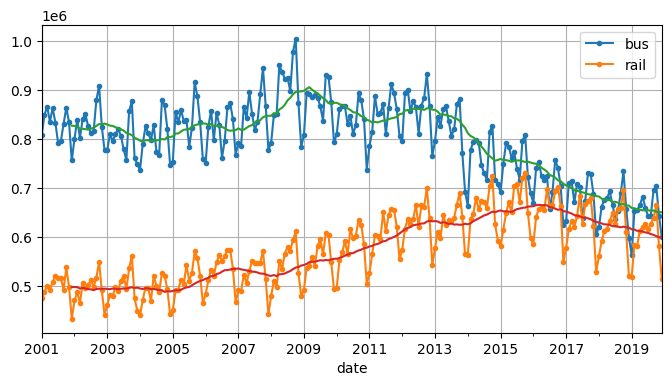

In [15]:
fig, ax = plt.subplots(1, 1, figsize= (8, 4))
df_monthly[period].plot(ax= ax, marker= '.')
rolling_avg_12_months.plot(ax= ax, grid= True, legend= False)
plt.show()

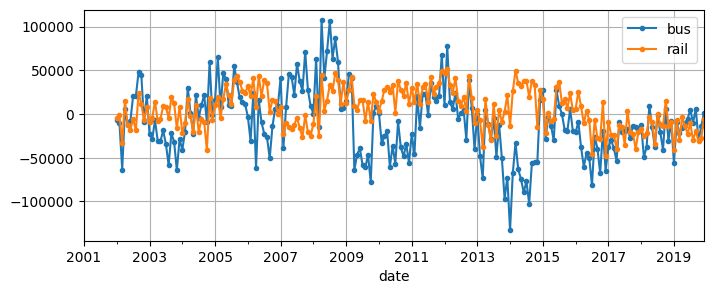

In [16]:
df_monthly.diff(12)[period].plot(grid= True, marker= '.', figsize= (8, 3))
plt.show()

## The ARMA Model Family

In [17]:
origin, today = '2019-01-01', '2019-05-31'
rail_series = df.loc[origin:today, 'rail'].asfreq('D')

In [18]:
model = ARIMA(
    rail_series,
    order= (1, 0, 0),
    seasonal_order= (0, 1, 1, 7)
)
model = model.fit()
y_pred = model.forecast()

In [19]:
y_pred.iloc[0]    # ARIMA forecast

np.float64(427758.6262875742)

In [20]:
df['rail'].loc['2019-06-01']    # target value

np.int64(379044)

In [21]:
df['rail'].loc['2019-05-25']    # naive forecast

np.int64(426932)

In [22]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.loc[origin:end_date]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today],  # train on data up to "today"
                  order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, 7))
    model = model.fit()  # note that we retrain the model every day!
    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)

y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean()  # returns 32,040.7

In [23]:
y_preds

2019-03-01    696955.515289
2019-03-02    342139.361035
2019-03-03    253320.415572
2019-03-04    633245.752907
2019-03-05    696723.448693
                  ...      
2019-05-27    736799.259397
2019-05-28    403824.542160
2019-05-29    721311.482951
2019-05-30    726614.005060
2019-05-31    699026.523614
Freq: D, Length: 92, dtype: float64

In [24]:
mae

np.float64(32040.72009292839)

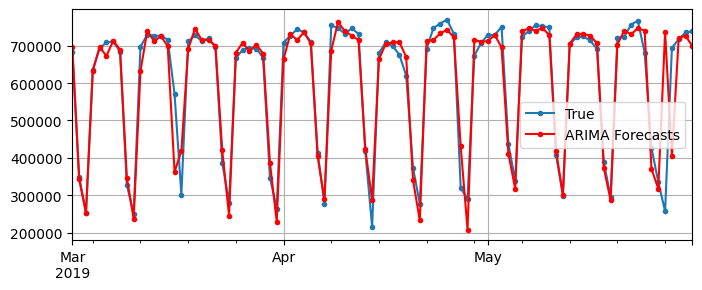

In [25]:
fig, ax = plt.subplots(figsize= (8, 3))
rail_series.loc[time_period].plot(label= 'True', ax= ax, marker= '.', grid= True)
y_preds.plot(color= 'r', marker= '.', label= 'ARIMA Forecasts', ax= ax)
plt.legend()
plt.grid()
plt.show()

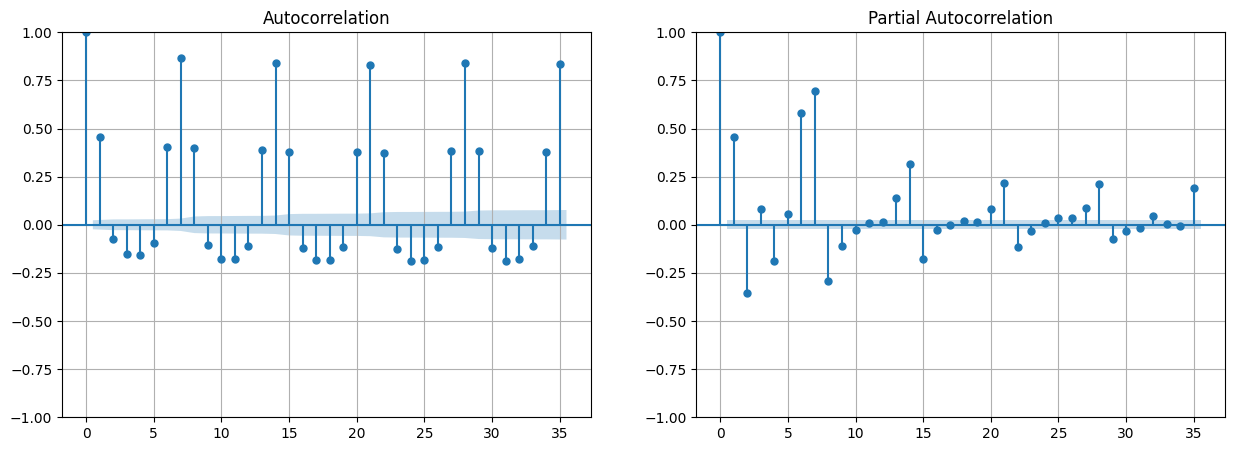

In [26]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
plot_acf(df[period]["rail"], ax=axs[0], lags=35)
axs[0].grid()
plot_pacf(df[period]["rail"], ax=axs[1], lags=35, method="ywm")
axs[1].grid()
plt.show()

## Preparing data for ML model

In [27]:
series = [0, 1, 2, 3, 4, 5]
dataset = tf.keras.utils.timeseries_dataset_from_array(
    series,
    targets= series[3:],
    sequence_length= 3,
    batch_size= 2
)

I0000 00:00:1778252165.457810      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [28]:
list(dataset)

[(<tf.Tensor: shape=(2, 3), dtype=int32, numpy=
  array([[0, 1, 2],
         [1, 2, 3]], dtype=int32)>,
  <tf.Tensor: shape=(2,), dtype=int32, numpy=array([3, 4], dtype=int32)>),
 (<tf.Tensor: shape=(1, 3), dtype=int32, numpy=array([[2, 3, 4]], dtype=int32)>,
  <tf.Tensor: shape=(1,), dtype=int32, numpy=array([5], dtype=int32)>)]

In [29]:
for window_dataset in tf.data.Dataset.range(6).window(4, shift= 1):
    for element in window_dataset:
        print(f'{element}', end=' ')
    print()

0 1 2 3 
1 2 3 4 
2 3 4 5 
3 4 5 
4 5 
5 


In [30]:
for window_dataset in tf.data.Dataset.range(6).window(4, shift= 1, drop_remainder= True):
    for element in window_dataset:
        print(f'{element}', end=' ')
    print()

0 1 2 3 
1 2 3 4 
2 3 4 5 


In [31]:
dataset = tf.data.Dataset.range(6).window(4, shift= 1, drop_remainder= True)
dataset = dataset.flat_map(lambda window_dataset: window_dataset.batch(4))
for window_tensor in dataset:
    print(f'{window_tensor}')

[0 1 2 3]
[1 2 3 4]
[2 3 4 5]


In [32]:
rail_train = df.loc['2016-01':'2018-12', 'rail'] / 1e6
rail_valid = df.loc['2019-01':'2019-05', 'rail'] / 1e6
rail_test = df.loc['2019-06', 'rail'] / 1e6

In [33]:
seq_len = 56
tf.random.set_seed(42)

train_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_train.to_numpy(),
    targets= rail_train[seq_len:],
    sequence_length= seq_len,
    batch_size= 32,
    shuffle= True,
    seed= 42
)

valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    rail_valid.to_numpy(),
    targets= rail_valid[seq_len:],
    sequence_length= seq_len,
    batch_size= 32
)

## Forecasting Using a Simple RNN

In [34]:
def fit_and_evaluate(model, train_set, valid_set, learning_rate, epochs=500):
    early_stopping_cb = tf.keras.callbacks.EarlyStopping(
        monitor= 'val_mae', 
        patience= 50, 
        restore_best_weights= True
    )
    opt = tf.keras.optimizers.SGD(learning_rate= learning_rate, momentum= 0.9)
    model.compile(loss=tf.keras.losses.Huber(), optimizer= opt, metrics= ['mae'])
    history = model.fit(
        train_set, 
        validation_data= valid_set, 
        epochs= epochs,
        callbacks= [early_stopping_cb]
    )
    valid_loss, valid_mae = model.evaluate(valid_set)
    return valid_mae * 1e6

In [35]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.Input(shape= [None, 1]),
    tf.keras.layers.SimpleRNN(1)
])

In [36]:
fit_and_evaluate(model, train_ds, valid_ds, learning_rate= 0.02)

Epoch 1/500


I0000 00:00:1778252169.176953     133 service.cc:152] XLA service 0x786aa006ff30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778252169.177011     133 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778252169.360116     133 cuda_dnn.cc:529] Loaded cuDNN version 91002


21/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0866 - mae: 0.3708

I0000 00:00:1778252169.745955     133 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0853 - mae: 0.3683 - val_loss: 0.0926 - val_mae: 0.3922
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0848 - mae: 0.3687 - val_loss: 0.0926 - val_mae: 0.3922
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0854 - mae: 0.3706 - val_loss: 0.0926 - val_mae: 0.3922
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0848 - mae: 0.3696 - val_loss: 0.0926 - val_mae: 0.3922
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0884 - mae: 0.3774 - val_loss: 0.0926 - val_mae: 0.3922
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0862 - mae: 0.3723 - val_loss: 0.0926 - val_mae: 0.3922
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0851 - mae: 0.3693 - val_loss: 0.0926 - val_mae: 0.3922
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0825 - mae: 0.3645 - val_loss: 0.0926 - val_mae: 0.3922
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0846 - mae: 0.

392219.4242477417

In [37]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.Input(shape= [None, 1]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

fit_and_evaluate(model, train_ds, valid_ds, learning_rate= 0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 0.1400 - mae: 0.4362 - val_loss: 0.0076 - val_mae: 0.1039
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0073 - mae: 0.0973 - val_loss: 0.0064 - val_mae: 0.0974
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0054 - mae: 0.0759 - val_loss: 0.0031 - val_mae: 0.0631
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0037 - mae: 0.0595 - val_loss: 0.0024 - val_mae: 0.0479
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - mae: 0.0538 - val_loss: 0.0023 - val_mae: 0.0451
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - mae: 0.0496 - val_loss: 0.0021 - val_mae: 0.0407
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0031 - mae: 0.0481 - val_loss: 0.0021 - val_mae: 0.0400
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - mae: 0.0446 - val_loss: 0.0025 - val_mae: 0.0460
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.00

31948.145478963852

## Forecasting Using DeepRNN

In [38]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.Input(shape= [None, 1]),
    tf.keras.layers.SimpleRNN(32, return_sequences= True),
    tf.keras.layers.SimpleRNN(32, return_sequences= True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1)
])

fit_and_evaluate(model, train_ds, valid_ds, learning_rate= 0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.1355 - mae: 0.3658 - val_loss: 0.0035 - val_mae: 0.0618
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0095 - mae: 0.1056 - val_loss: 0.0024 - val_mae: 0.0472
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0052 - mae: 0.0715 - val_loss: 0.0035 - val_mae: 0.0635
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0045 - mae: 0.0618 - val_loss: 0.0061 - val_mae: 0.0943
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0044 - mae: 0.0684 - val_loss: 0.0022 - val_mae: 0.0410
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - mae: 0.0531 - val_loss: 0.0036 - val_mae: 0.0649
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0046 - mae: 0.0628 - val_loss: 0.0020 - val_mae: 0.0384
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0039 - mae: 0.0547 - val_loss: 0.0019 - val_mae: 0.0366
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

28518.63205432892

## Forecasting Multivariate Time Series

In [39]:
df_mulvar = df[['bus', 'rail']] / 1e6
df_mulvar['next_day_type'] = df['day_type'].shift(-1)
df_mulvar = pd.get_dummies(df_mulvar, dtype= float)

In [40]:
df_mulvar.head()

,bus,rail,next_day_type_A,next_day_type_U,next_day_type_W
date,,,,,
2001-01-01,0.297192,0.126455,0.0,0.0,1.0
2001-01-02,0.780827,0.501952,0.0,0.0,1.0
2001-01-03,0.824923,0.536432,0.0,0.0,1.0
2001-01-04,0.870021,0.550011,0.0,0.0,1.0
2001-01-05,0.890426,0.557917,1.0,0.0,0.0


In [41]:
mulvar_train = df_mulvar['2016-01':'2018-12']
mulvar_valid = df_mulvar['2019-01':'2019-05']
mulvar_test = df_mulvar['2019-06':]

In [42]:
tf.random.set_seed(42)

seq_length = 56
train_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_train.to_numpy(),
    targets= mulvar_train[['bus', 'rail']][seq_length:],  # 2 targets per day
    sequence_length= seq_length,
    batch_size= 32,
    shuffle= True,
    seed= 42
)
valid_multask_ds = tf.keras.utils.timeseries_dataset_from_array(
    mulvar_valid.to_numpy(),
    targets= mulvar_valid[['bus', 'rail']][seq_length:],
    sequence_length= seq_length,
    batch_size= 32
)

tf.random.set_seed(42)
multask_model = tf.keras.Sequential([
    tf.keras.Input(shape= [None, 5]),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(2)
])

fit_and_evaluate(multask_model, train_multask_ds, valid_multask_ds, learning_rate= 0.02)

Epoch 1/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 0.1599 - mae: 0.4132 - val_loss: 0.0097 - val_mae: 0.1147
Epoch 2/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0070 - mae: 0.0916 - val_loss: 0.0022 - val_mae: 0.0531
Epoch 3/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027 - mae: 0.0508 - val_loss: 0.0013 - val_mae: 0.0394
Epoch 4/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 - mae: 0.0451 - val_loss: 0.0012 - val_mae: 0.0382
Epoch 5/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - mae: 0.0428 - val_loss: 0.0012 - val_mae: 0.0375
Epoch 6/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0428 - val_loss: 9.5080e-04 - val_mae: 0.0338
Epoch 7/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - mae: 0.0414 - val_loss: 9.7739e-04 - val_mae: 0.0342
Epoch 8/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0016 - mae: 0.0389 - val_loss: 9.6149e-04 - val_mae: 0.0337
Epoch 9/500
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

24479.31468486786

In [43]:
Y_preds_valid = multask_model.predict(valid_multask_ds)
for idx, name in enumerate(['bus', 'rail']):
    mae = 1e6 * tf.keras.metrics.MeanAbsoluteError()(
        mulvar_valid[name][seq_length:], Y_preds_valid[:, idx])
    print(name, int(mae))

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step
bus 26127
rail 22831


## Handling Long Sequences
### 1. Unstable Gradient Problem

In [44]:
class LNSimpleRNNCell(tf.keras.layers.Layer):
    def __init__(self, units, *, activation= 'tanh', **kwargs):
        super().__init__(**kwargs)
        self.state_size = units
        self.output_size = units
        self.rnn_cell = tf.keras.layers.SimpleRNNCell(units, activation= None)
        self.layer_norm = tf.keras.layers.LayerNormalization()
        self.activation = tf.keras.activations.get(activation)

    def call(self, inputs, states):
        outputs, new_states = self.rnn_cell(inputs, states)
        norm_outputs = self.activation(self.layer_norm(outputs))
        return norm_outputs, [norm_outputs]

In [45]:
custom_ln_model = tf.keras.Sequential([
    tf.keras.Input(shape= [None, 5]),
    tf.keras.layers.RNN(LNSimpleRNNCell(units= 32), return_sequences= True),
    tf.keras.layers.Dense(14)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'ln_simple_rnn_cell', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


### 2. Short-Term Memory Problem
#### Long-Short Term Memory (LSTM) Cells

In [46]:
lstm_model = tf.keras.Sequential([
    tf.keras.Input(shape= [None, 5]),
    tf.keras.layers.LSTM(32, return_sequences= True),
    tf.keras.layers.Dense(14)
])

In [47]:
conv_rnn_model = tf.keras.Sequential([
    tf.keras.layers.Conv1D(filters=32, kernel_size=4, strides=2,
                           activation="relu", input_shape=[None, 5]),
    tf.keras.layers.GRU(32, return_sequences=True),
    tf.keras.layers.Dense(14)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
